In [2]:

import sqlite3
import pandas as pd

conn = sqlite3.connect("hedge_fund.db")

print("Database connected successfully!")

Database connected successfully!


In [3]:

query = """
WITH price_history AS (
    SELECT
        date,
        ticker,
        close_price,
        LAG(close_price) OVER (
            PARTITION BY ticker
            ORDER BY date
        ) AS previous_close
    FROM daily_prices
)
SELECT
    date,
    ticker,
    ROUND(close_price, 2) AS close_price,
    ROUND(previous_close, 2) AS previous_close,
    ROUND(
        (close_price / previous_close - 1) * 100,
        2
    ) AS daily_return_pct
FROM price_history
WHERE previous_close IS NOT NULL
  AND previous_close > 0
ORDER BY ticker, date
LIMIT 20;
"""

display(pd.read_sql_query(query, conn))

,date,ticker,close_price,previous_close,daily_return_pct
0,2025-09-24,AAPL,251.38,253.49,-0.83
1,2025-09-25,AAPL,255.92,251.38,1.81
2,2025-09-26,AAPL,254.52,255.92,-0.55
3,2025-09-29,AAPL,253.49,254.52,-0.40
4,2025-09-30,AAPL,253.69,253.49,0.08
5,2025-10-01,AAPL,254.51,253.69,0.32
6,2025-10-02,AAPL,256.18,254.51,0.66
7,2025-10-03,AAPL,257.07,256.18,0.35
8,2025-10-06,AAPL,255.75,257.07,-0.52
9,2025-10-07,AAPL,255.54,255.75,-0.08


In [4]:

query = """
WITH returns AS (
    SELECT
        ticker,
        date,
        close_price,
        LAG(close_price) OVER (
            PARTITION BY ticker
            ORDER BY date
        ) AS previous_close
    FROM daily_prices
)
SELECT
    ticker,
    COUNT(*) AS trading_days,
    ROUND(
        AVG((close_price / previous_close - 1) * 100),
        4
    ) AS avg_daily_return_pct,
    ROUND(
        MIN((close_price / previous_close - 1) * 100),
        2
    ) AS worst_day_pct,
    ROUND(
        MAX((close_price / previous_close - 1) * 100),
        2
    ) AS best_day_pct
FROM returns
WHERE previous_close > 0
GROUP BY ticker
ORDER BY ticker;
"""

summary = pd.read_sql_query(query, conn)
display(summary)

,ticker,trading_days,avg_daily_return_pct,worst_day_pct,best_day_pct
0,AAPL,249,0.1288,-7.35,4.84
1,BLK,249,0.0085,-7.17,6.63
2,GS,249,0.0981,-7.47,9.00
3,JPM,249,0.0649,-4.66,3.95
4,MSFT,249,0.0180,-9.99,15.51


In [5]:

import numpy as np

query = """
WITH returns AS (
    SELECT
        ticker,
        date,
        close_price,
        LAG(close_price) OVER (
            PARTITION BY ticker
            ORDER BY date
        ) AS previous_close
    FROM daily_prices
)
SELECT
    ticker,
    date,
    (close_price / previous_close - 1) AS daily_return
FROM returns
WHERE previous_close > 0
ORDER BY ticker, date;
"""

daily_returns = pd.read_sql_query(query, conn)

risk_summary = (
    daily_returns.groupby("ticker")["daily_return"]
    .agg(
        observations="count",
        average_daily_return="mean",
        daily_volatility="std"
    )
)

risk_summary["annualized_volatility_pct"] = (
    risk_summary["daily_volatility"]
    * np.sqrt(252)
    * 100
)

display(risk_summary.round(4))

,observations,average_daily_return,daily_volatility,annualized_volatility_pct
ticker,,,,
AAPL,249,0.0013,0.0155,24.5929
BLK,249,0.0001,0.0173,27.5058
GS,249,0.0010,0.0203,32.2236
JPM,249,0.0006,0.0140,22.2203
MSFT,249,0.0002,0.0206,32.6606


In [6]:

# Calculate compounded cumulative returns
daily_returns = daily_returns.sort_values(
    ["ticker", "date"]
).copy()

daily_returns["cumulative_return"] = (
    daily_returns.groupby("ticker")["daily_return"]
    .transform(lambda r: (1 + r).cumprod() - 1)
)

# Final cumulative return for each stock
cumulative_summary = (
    daily_returns.groupby("ticker")["cumulative_return"]
    .last()
    .mul(100)
    .round(2)
    .to_frame("cumulative_return_pct")
)

display(cumulative_summary)

,cumulative_return_pct
ticker,
AAPL,33.72
BLK,-1.61
GS,21.32
JPM,14.72
MSFT,-0.69


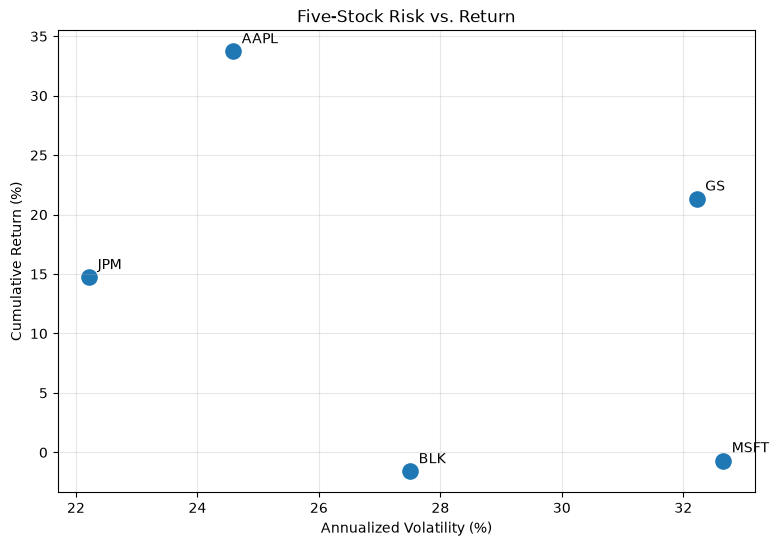

In [7]:

import matplotlib.pyplot as plt

comparison = risk_summary.join(cumulative_summary)

plt.figure(figsize=(9, 6))

plt.scatter(
    comparison["annualized_volatility_pct"],
    comparison["cumulative_return_pct"],
    s=120
)

for ticker, row in comparison.iterrows():
    plt.annotate(
        ticker,
        (
            row["annualized_volatility_pct"],
            row["cumulative_return_pct"]
        ),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Cumulative Return (%)")
plt.title("Five-Stock Risk vs. Return")
plt.grid(alpha=0.3)
plt.show()

### Day 17 — Research Conclusion

**Objective:** Use SQL window functions and Python to analyze daily stock returns, historical volatility and cumulative performance for five equities.

**Methodology:** Retrieved closing prices from the SQLite `daily_prices` table. Used SQL `LAG()` to calculate previous-day prices and daily returns. Calculated annualized volatility using sample standard deviation and an assumption of 252 trading days.

**Findings:** JPM had the lowest estimated annualized volatility at 22.22%, while MSFT had the highest at 32.66%. The risk-versus-return chart illustrates how historical volatility and realized cumulative returns differed across the five stocks during the observation period.

**Limitations:** The analysis uses historical closing prices, excludes dividends and transaction costs, and does not predict future returns or volatility.
